In [ ]:
#Codigo de entramiento sin Aumentación

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar el dataset
train_df = pd.read_csv('Datos_csv\sign_mnist_train.csv')
test_df = pd.read_csv('Datos_csv\sign_mnist_test.csv')

# Preprocesar los datos
def preprocess_data(df):
    labels = df['label'].values
    images = df.drop(columns=['label']).values
    images = images.reshape(-1, 28, 28, 1)  # Reformar a (28, 28, 1)
    images = images / 255.0  # Normalizar los valores de píxeles
    return images, labels

# Preprocesar datos de entrenamiento y prueba
X_train, y_train = preprocess_data(train_df)
X_test, y_test = preprocess_data(test_df)

# Convertir etiquetas a one-hot encoding
num_classes = 25  # Excluye las letras J y Z
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# Definir el modelo CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.5),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')  # 24 clases (A-Y, excluyendo J y Z)
])

# Compilar el modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=10, batch_size=32,
                    validation_data=(X_test, y_test))

# Evaluar el modelo
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nPrecisión en el conjunto de prueba: {test_acc:.4f}')

# Guardar el modelo
model.save('Modelo_lenguje_senas_5.keras')

In [ ]:
#Codigo de entramiento con Aumentación

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import pandas as pd

# Leer los datos
train_df = pd.read_csv("Datos_csv/sign_mnist_train.csv")
test_df = pd.read_csv('Datos_csv/sign_mnist_test.csv')

# Preprocesar los datos
def preprocess_data(df):
    labels = df['label'].values
    images = df.drop(columns=['label']).values
    images = images.reshape(-1, 28, 28, 1)  # Reformar a (28, 28, 1)
    images = images / 255.0  # Normalizar los valores de píxeles
    return images, labels

# Preprocesar datos de entrenamiento y prueba
X_train, y_train = preprocess_data(train_df)
X_test, y_test = preprocess_data(test_df)

# Verificar el valor máximo de las etiquetas
max_label = max(np.max(y_train), np.max(y_test))
print(f"Valor máximo de las etiquetas: {max_label}")

# Ajustar num_classes según el valor máximo de las etiquetas
num_classes = max_label + 1
print(f"Número de clases ajustado: {num_classes}")

# Convertir etiquetas a one-hot encoding
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# Aumentación de datos más agresiva
datagen = ImageDataGenerator(
    rotation_range=30,  # Rotar imágenes hasta 30 grados
    width_shift_range=0.3,  # Desplazar imágenes horizontalmente hasta un 30%
    height_shift_range=0.3,  # Desplazar imágenes verticalmente hasta un 30%
    zoom_range=0.3,  # Zoom aleatorio hasta un 30%
    shear_range=0.3,  # Inclinación aleatoria hasta un 30%
    fill_mode='nearest'
)

# Definir el modelo CNN mejorado
model = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),  # Regularización

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),  # Regularización

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),  # Regularización

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),  # Regularización

    layers.Dense(num_classes, activation='softmax')
])

# Compilar el modelo
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitorear la pérdida en el conjunto de validación
    patience=15,  # Número de épocas sin mejora antes de detener el entrenamiento
    restore_best_weights=True  # Restaurar los mejores pesos encontrados
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Monitorear la pérdida en el conjunto de validación
    factor=0.2,  # Reducir la tasa de aprendizaje en un 20%
    patience=5,  # Número de épocas sin mejora antes de reducir la tasa de aprendizaje
    min_lr=1e-6  # Tasa de aprendizaje mínima
)

# Entrenar el modelo
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),  # Aumentar el tamaño del batch
    epochs=200,  # Número máximo de épocas
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr]
)

# Evaluar el modelo
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nPrecisión en el conjunto de prueba: {test_acc:.4f}')

# Guardar el modelo
model.save('Modelo_lenguaje_senas_final_mejorado.keras')


Advertencia: No se encontró el archivo de historial. Omitiendo gráficas de entrenamiento.
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


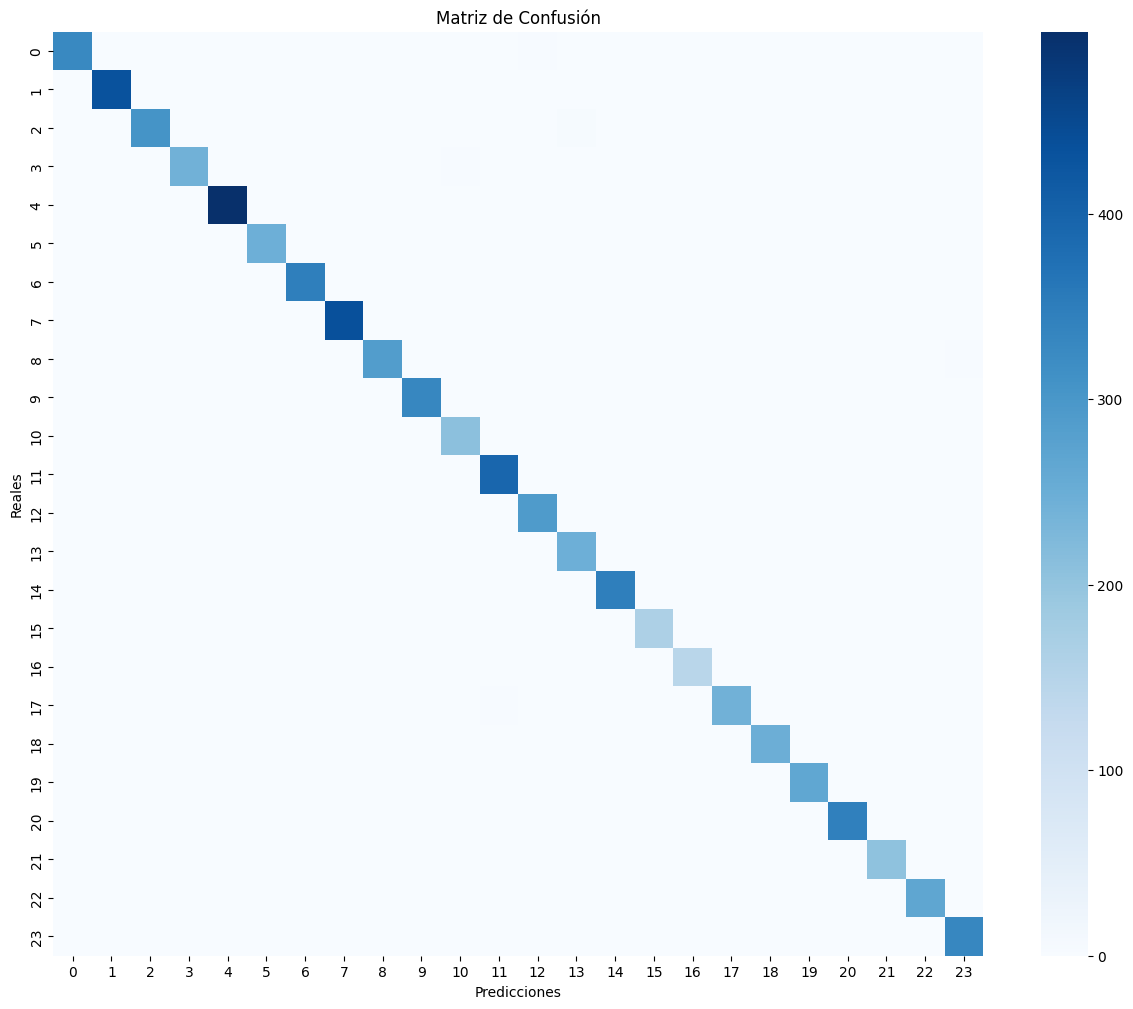

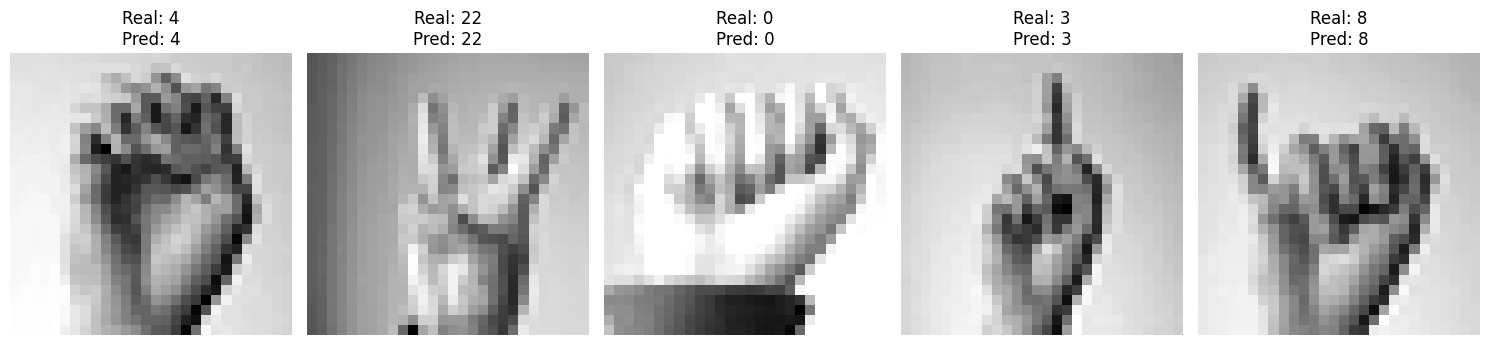

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [4]:
# Visualizaciones_Modelo_Entrenado.py
import tensorflow as tf
from tensorflow.keras.utils import to_categorical, plot_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pickle

# 1. Cargar el modelo entrenado
model = tf.keras.models.load_model('Modelo_lenguaje_senas_final_mejorado.keras')

# 2. Cargar el historial de entrenamiento (si se guardó)
try:
    with open('history.pkl', 'rb') as f:
        history = pickle.load(f)
except FileNotFoundError:
    print("Advertencia: No se encontró el archivo de historial. Omitiendo gráficas de entrenamiento.")
    history = None

# 3. Cargar y preprocesar datos de prueba
test_df = pd.read_csv('Datos_csv/sign_mnist_test.csv')

def preprocess_data(df):
    labels = df['label'].values
    images = df.drop(columns=['label']).values
    images = images.reshape(-1, 28, 28, 1)
    images = images / 255.0
    return images, labels

X_test, y_test = preprocess_data(test_df)
y_test_onehot = to_categorical(y_test, num_classes=model.output_shape[-1])  # Usar la forma del modelo

# 4. Generar predicciones
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = y_test  # y_test ya no está en one-hot

# ==============================
# Gráficas
# ==============================

# A. Curvas de Entrenamiento (si history está disponible)
if history is not None:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Entrenamiento')
    plt.plot(history['val_accuracy'], label='Validación')
    plt.title('Precisión por Época')
    plt.ylabel('Precisión')
    plt.xlabel('Época')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Entrenamiento')
    plt.plot(history['val_loss'], label='Validación')
    plt.title('Pérdida por Época')
    plt.ylabel('Pérdida')
    plt.xlabel('Época')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_curves.png')
    plt.show()

# B. Matriz de Confusión
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=True)  # annot=False para muchas clases
plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Reales')
plt.savefig('confusion_matrix.png')
plt.show()

# C. Ejemplos de Predicciones
class_names = [str(i) for i in range(model.output_shape[-1])]  # Ajusta si tienes nombres reales (ej. 'A', 'B')

plt.figure(figsize=(15, 7))
for i in range(5):
    idx = np.random.randint(len(X_test))
    img = X_test[idx].reshape(28, 28)
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Real: {class_names[y_true_classes[idx]]}\nPred: {class_names[y_pred_classes[idx]]}')
    plt.axis('off')

plt.tight_layout()
plt.savefig('prediction_examples.png')
plt.show()

# D. Arquitectura del Modelo
try:
    plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
except ImportError:
    print("Instala pydot y graphviz para generar la arquitectura: pip install pydot graphviz")

In [ ]:
# Código de entrenamiento con Aumentación y Visualizaciones

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # <-- Añadido para gráficos
from sklearn.metrics import confusion_matrix  # <-- Añadido para matriz de confusión
import seaborn as sns  # <-- Añadido para visualización de matriz

# [...] (El resto de tus imports y código de preprocesamiento se mantiene igual)

# Entrenar el modelo
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr]
)

# Evaluar el modelo
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nPrecisión en el conjunto de prueba: {test_acc:.4f}')

# ==============================================
# SECCIÓN NUEVA: VISUALIZACIONES (AGREGAR DESDE AQUÍ)
# ==============================================

# 1. Curvas de Entrenamiento (Accuracy/Loss)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión por Época')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida por Época')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png')  # Guardar imagen
plt.show()

# 2. Matriz de Confusión
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.savefig('confusion_matrix.png')  # Guardar imagen
plt.show()

# 3. Ejemplos de Predicciones
class_names = [str(i) for i in range(num_classes)]  # Asume etiquetas numéricas 0-24 (A-Y)

plt.figure(figsize=(15, 7))
for i in range(5):
    idx = np.random.choice(len(X_test))
    img = X_test[idx].reshape(28, 28)  # Eliminar dimensión del canal
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Real: {class_names[y_true_classes[idx]]}\nPred: {class_names[y_pred_classes[idx]]}')
    plt.axis('off')

plt.tight_layout()
plt.savefig('predictions_examples.png')  # Guardar imagen
plt.show()

# 4. Arquitectura del Modelo (Requiere pydot y graphviz)
try:
    from tensorflow.keras.utils import plot_model
    plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
except ImportError:
    print("Instala pydot y graphviz para esta gráfica: pip install pydot graphviz")

# ==============================================
# FIN DE SECCIÓN NUEVA
# ==============================================

# Guardar el modelo
model.save('Modelo_lenguaje_senas_final_mejorado.keras')

In [ ]:
#Codigo que ejecuta el modelo con el menu de opciones (camara, pantalla y archivo)

import tensorflow as tf
import numpy as np
import cv2
import mediapipe as mp
from mss import mss  # Para capturar la pantalla

# Cargar el modelo entrenado
model = tf.keras.models.load_model('Modelo_lenguje_senas_5.keras')

# Inicializar MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=1, min_detection_confidence=0.7)
mp_drawing = mp.solutions.drawing_utils

# Etiquetas de las clases (excluyendo J y Z)
class_labels = "ABCDEFGHIKLMNOPQRSTUVWXY"

# Función para preprocesar la imagen
def preprocess_image(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convertir a escala de grises
    image = cv2.resize(image, (28, 28))  # Redimensionar a 28x28
    image = image / 255.0  # Normalizar
    image = image.reshape(1, 28, 28, 1)  # Reformar para el modelo
    return image

# Función para predecir la clase de la imagen
def predict_image(image):
    prediction = model.predict(image)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)
    return predicted_class, confidence

# Menú para elegir entre usar la cámara, cargar una imagen o capturar la pantalla
def menu():
    print("1. Usar la cámara")
    print("2. Cargar una imagen")
    print("3. Capturar un recuadro de 600x600 de la pantalla")
    choice = input("Elige una opción (1, 2 o 3): ")
    return choice

# Opción 1: Usar la cámara
def use_camera():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: No se pudo abrir la cámara.")
        return

    print("Cámara activada. Presiona 'q' para salir.")

    while True:
        # Capturar un frame de la cámara
        ret, frame = cap.read()
        if not ret:
            print("Error: No se pudo capturar el frame.")
            break

        # Convertir el frame a RGB (MediaPipe requiere imágenes en RGB)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Procesar el frame con MediaPipe Hands
        results = hands.process(rgb_frame)

        # Si se detecta una mano, dibujar un recuadro azul alrededor de ella
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                # Obtener las coordenadas de los landmarks de la mano
                h, w, _ = frame.shape
                x_min, y_min, x_max, y_max = w, h, 0, 0
                for landmark in hand_landmarks.landmark:
                    x, y = int(landmark.x * w), int(landmark.y * h)
                    if x < x_min:
                        x_min = x
                    if x > x_max:
                        x_max = x
                    if y < y_min:
                        y_min = y
                    if y > y_max:
                        y_max = y

                # Dibujar un recuadro azul alrededor de la mano
                cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

                # Recortar la región de la mano
                hand_region = frame[y_min:y_max, x_min:x_max]

                # Si la región de la mano es válida, preprocesarla y predecir
                if hand_region.size != 0:
                    processed_image = preprocess_image(hand_region)
                    predicted_class, confidence = predict_image(processed_image)

                    # Verificar que predicted_class esté dentro del rango válido
                    if 0 <= predicted_class < len(class_labels):
                        label = f"Prediccion: {class_labels[predicted_class]} (Confianza: {confidence:.2f})"
                    else:
                        label = "Prediccion: Desconocido"

                    # Mostrar la predicción en el frame
                    cv2.putText(frame, label, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

        # Mostrar el frame en una ventana
        cv2.imshow('Lenguaje de Señas - Detección en Tiempo Real', frame)

        # Salir si se presiona la tecla 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

# Opción 2: Cargar una imagen
def load_image():
    image_path = input("Introduce la ruta de la imagen: ")
    image = cv2.imread(image_path)
    if image is None:
        print("Error: No se pudo cargar la imagen.")
        return

    # Convertir la imagen a RGB (MediaPipe requiere imágenes en RGB)
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Procesar la imagen con MediaPipe Hands
    results = hands.process(rgb_image)

    # Si se detecta una mano, dibujar un recuadro azul alrededor de ella
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            # Obtener las coordenadas de los landmarks de la mano
            h, w, _ = image.shape
            x_min, y_min, x_max, y_max = w, h, 0, 0
            for landmark in hand_landmarks.landmark:
                x, y = int(landmark.x * w), int(landmark.y * h)
                if x < x_min:
                    x_min = x
                if x > x_max:
                    x_max = x
                if y < y_min:
                    y_min = y
                if y > y_max:
                    y_max = y

            # Dibujar un recuadro azul alrededor de la mano
            cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

            # Recortar la región de la mano
            hand_region = image[y_min:y_max, x_min:x_max]

            # Si la región de la mano es válida, preprocesarla y predecir
            if hand_region.size != 0:
                processed_image = preprocess_image(hand_region)
                predicted_class, confidence = predict_image(processed_image)

                # Verificar que predicted_class esté dentro del rango válido
                if 0 <= predicted_class < len(class_labels):
                    label = f"Prediccion: {class_labels[predicted_class]} (Confianza: {confidence:.2f})"
                else:
                    label = "Prediccion: Desconocido"

                # Mostrar la predicción en la imagen
                cv2.putText(image, label, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

    # Mostrar la imagen con la predicción
    cv2.imshow('Imagen Cargada', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

# Opción 3: Capturar un recuadro de 600x600 de la pantalla
def capture_screen():
    print("Captura de pantalla activada. Presiona 'q' para salir.")

    # Configurar la captura de pantalla con mss
    with mss() as sct:
        # Obtener las dimensiones de la pantalla
        screen_width = sct.monitors[1]["width"]
        screen_height = sct.monitors[1]["height"]

        # Definir el área de captura (600x600 píxeles centrados)
        capture_width = 600
        capture_height = 600
        monitor = {
            "top": (screen_height - capture_height) // 2,  # Centrar verticalmente
            "left": (screen_width - capture_width) // 2,    # Centrar horizontalmente
            "width": capture_width,
            "height": capture_height
        }

        while True:
            # Capturar el recuadro de la pantalla
            screenshot = np.array(sct.grab(monitor))

            # Convertir la imagen a RGB (MediaPipe requiere imágenes en RGB)
            rgb_frame = cv2.cvtColor(screenshot, cv2.COLOR_BGRA2RGB)

            # Procesar el frame con MediaPipe Hands
            results = hands.process(rgb_frame)

            # Si se detecta una mano, dibujar un recuadro azul alrededor de ella
            if results.multi_hand_landmarks:
                for hand_landmarks in results.multi_hand_landmarks:
                    # Obtener las coordenadas de los landmarks de la mano
                    h, w, _ = screenshot.shape
                    x_min, y_min, x_max, y_max = w, h, 0, 0
                    for landmark in hand_landmarks.landmark:
                        x, y = int(landmark.x * w), int(landmark.y * h)
                        if x < x_min:
                            x_min = x
                        if x > x_max:
                            x_max = x
                        if y < y_min:
                            y_min = y
                        if y > y_max:
                            y_max = y

                    # Dibujar un recuadro azul alrededor de la mano
                    cv2.rectangle(screenshot, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

                    # Recortar la región de la mano
                    hand_region = screenshot[y_min:y_max, x_min:x_max]

                    # Si la región de la mano es válida, preprocesarla y predecir
                    if hand_region.size != 0:
                        processed_image = preprocess_image(hand_region)
                        predicted_class, confidence = predict_image(processed_image)

                        # Verificar que predicted_class esté dentro del rango válido
                        if 0 <= predicted_class < len(class_labels):
                            label = f"Prediccion: {class_labels[predicted_class]} (Confianza: {confidence:.2f})"
                        else:
                            label = "Prediccion: Desconocido"

                        # Mostrar la predicción en el frame
                        cv2.putText(screenshot, label, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

            # Mostrar el frame en una ventana
            cv2.imshow('Captura de Pantalla - Detección de Manos', screenshot)

            # Salir si se presiona la tecla 'q'
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    cv2.destroyAllWindows()

# Menú principal
choice = menu()
if choice == '1':
    use_camera()
elif choice == '2':
    load_image()
elif choice == '3':
    capture_screen()
else:
    print("Opción no válida.")

In [ ]:
#Codigo solo de captura de pantalla

import tensorflow as tf
import numpy as np
import cv2
import mediapipe as mp
from mss import mss

# Cargar el modelo entrenado
model = tf.keras.models.load_model('Modelo_pro.keras')

# Inicializar MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=1, min_detection_confidence=0.7)

# Etiquetas de las clases (excluyendo J y Z)
class_labels = "ABCDEFGHIKLMNOPQRSTUVWXY"

# Función para preprocesar la imagen
def preprocess_image(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convertir a escala de grises
    image = cv2.resize(image, (28, 28))  # Redimensionar a 28x28
    image = image / 255.0  # Normalizar
    image = image.reshape(1, 28, 28, 1)  # Reformar para el modelo
    return image

# Función para predecir la clase de la imagen
def predict_image(image):
    prediction = model.predict(image)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)
    return predicted_class, confidence

# Configurar la captura de pantalla con mss
with mss() as sct:
    # Definir el área de captura (600x600 píxeles centrados)
    screen_width = sct.monitors[1]["width"]
    screen_height = sct.monitors[1]["height"]
    monitor = {
        "top": (screen_height - 600) // 2,  # Centrar verticalmente
        "left": (screen_width - 600) // 2,   # Centrar horizontalmente
        "width": 600,
        "height": 600
    }

    print("Captura de pantalla activada. Presiona 'q' para salir.")

    while True:
        # Capturar el recuadro de la pantalla
        screenshot = np.array(sct.grab(monitor))

        # Convertir la imagen a RGB (MediaPipe requiere imágenes en RGB)
        rgb_frame = cv2.cvtColor(screenshot, cv2.COLOR_BGRA2RGB)

        # Procesar el frame con MediaPipe Hands
        results = hands.process(rgb_frame)

        # Si se detecta una mano, dibujar un recuadro azul alrededor de ella
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                # Obtener las coordenadas de los landmarks de la mano
                h, w, _ = screenshot.shape
                x_min, y_min, x_max, y_max = w, h, 0, 0
                for landmark in hand_landmarks.landmark:
                    x, y = int(landmark.x * w), int(landmark.y * h)
                    if x < x_min:
                        x_min = x
                    if x > x_max:
                        x_max = x
                    if y < y_min:
                        y_min = y
                    if y > y_max:
                        y_max = y

                # Dibujar un recuadro azul alrededor de la mano
                cv2.rectangle(screenshot, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

                # Recortar la región de la mano
                hand_region = screenshot[y_min:y_max, x_min:x_max]

                # Si la región de la mano es válida, preprocesarla y predecir
                if hand_region.size != 0:
                    processed_image = preprocess_image(hand_region)
                    predicted_class, confidence = predict_image(processed_image)

                    # Verificar que predicted_class esté dentro del rango válido
                    if 0 <= predicted_class < len(class_labels):
                        label = f"Prediccion: {class_labels[predicted_class]} (Confianza: {confidence:.2f})"
                    else:
                        label = "Prediccion: Desconocido"

                    # Mostrar la predicción en el frame
                    cv2.putText(screenshot, label, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

        # Mostrar el frame en una ventana
        cv2.imshow('Captura de Pantalla - Detección de Manos', screenshot)

        # Salir si se presiona la tecla 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cv2.destroyAllWindows()